In [272]:
import yfinance as yf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [273]:
Apple = yf.download("AAPL", start = "2010-01-01", end = "2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [274]:
Apple

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406480,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417557,6.453779,6.383729,6.424143,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345712,6.346311,6.258302,6.295421,447610800
...,...,...,...,...,...
2023-12-22,191.433090,193.222829,190.810137,192.995392,37149600
2023-12-26,190.889267,191.719862,190.671728,191.442997,28919300


In [275]:
ticker = ["SPY", "AAPL", "KO"]

In [276]:
stocks = yf.download(ticker, start = "2010-01-01", end = "2024-01-01") # Shift + Tab will show what the function is 

[*********************100%***********************]  3 of 3 completed


# Section 1: Creating datasets and making edits to them. Using dataframes from the dataset as well

In [277]:
stocks

Price            Close                               High             \
Ticker            AAPL         KO         SPY        AAPL         KO   
Date                                                                   
2010-01-04    6.406480  17.316332   84.796364    6.421149  17.370977   
2010-01-05    6.417557  17.106861   85.020836    6.453779  17.301155   
2010-01-06    6.315477  17.100786   85.080673    6.443002  17.134179   
2010-01-07    6.303801  17.058285   85.439865    6.346310  17.112930   
2010-01-08    6.345712  16.742565   85.724182    6.346311  16.891320   
...                ...        ...         ...         ...        ...   
2023-12-22  191.433090  54.594421  460.964417  193.222829  54.725477   
2023-12-26  190.889267  54.819088  462.910858  191.719862  54.959504   
2023-12-27  190.988113  54.959507  463.747864  191.334202  55.015675   
2023-12-28  191.413345  54.996948  463.923004  192.481259  55.109281   
2023-12-29  190.375061  55.165451  462.579956  192.224126  55.212256   

Price                          Low                               Open  \
Ticker             SPY        AAPL         KO         SPY        AAPL   
Date                                                                    
2010-01-04   84.841256    6.357686  17.273831   83.434594    6.389118   
2010-01-05   85.058249    6.383729  17.043109   84.437221    6.424143   
2010-01-06   85.290175    6.308891  16.994532   84.871171    6.417557   
2010-01-07   85.544616    6.258000  16.924709   84.684156    6.338826   
2010-01-08   85.761596    6.258302  16.621132   85.043300    6.295421   
...                ...         ...        ...         ...         ...   
2023-12-22  462.648093  190.810137  54.313587  459.066660  192.995392   
2023-12-26  463.815943  190.671728  54.351029  461.295314  191.442997   
2023-12-27  463.893840  188.951173  54.669313  462.171256  190.335512   
2023-12-28  464.759957  191.007931  54.791001  463.504528  191.967075   
2023-12-29  464.253891  189.584012  54.884616  460.623780  191.729722   

Price                                 Volume                       
Ticker             KO         SPY       AAPL        KO        SPY  
Date                                                               
2010-01-04  17.352761   84.078068  493729600  13870400  118944600  
2010-01-05  17.258652   84.743996  601904800  23172400  111579900  
2010-01-06  17.106857   84.938509  552160000  19264600  116074400  
2010-01-07  17.100787   84.923588  477131200  13234600  131091100  
2010-01-08  16.836675   85.215389  447610800  28712400  126402800  
...               ...         ...        ...       ...        ...  
2023-12-22  54.407197  461.168784   37149600   9029400   67160400  
2023-12-26  54.351029  461.373188   28919300   6422500   55387000  
2023-12-27  54.893979  462.706514   48087700   8560100   68000300  
2023-12-28  54.903338  464.107918   34049900   8400100   77158100  
2023-12-29  54.987590  463.728345   42672100   9244300  122283100  

[3522 rows x 15 columns]

In [278]:
stocks.head() # The first five data points 

Price          Close                            High                        \
Ticker          AAPL         KO        SPY      AAPL         KO        SPY   
Date                                                                         
2010-01-04  6.406480  17.316332  84.796364  6.421149  17.370977  84.841256   
2010-01-05  6.417557  17.106861  85.020836  6.453779  17.301155  85.058249   
2010-01-06  6.315477  17.100786  85.080673  6.443002  17.134179  85.290175   
2010-01-07  6.303801  17.058285  85.439865  6.346310  17.112930  85.544616   
2010-01-08  6.345712  16.742565  85.724182  6.346311  16.891320  85.761596   

Price            Low                            Open                        \
Ticker          AAPL         KO        SPY      AAPL         KO        SPY   
Date                                                                         
2010-01-04  6.357686  17.273831  83.434594  6.389118  17.352761  84.078068   
2010-01-05  6.383729  17.043109  84.437221  6.424143  17.258652  84.743996   
2010-01-06  6.308891  16.994532  84.871171  6.417557  17.106857  84.938509   
2010-01-07  6.258000  16.924709  84.684156  6.338826  17.100787  84.923588   
2010-01-08  6.258302  16.621132  85.043300  6.295421  16.836675  85.215389   

Price          Volume                       
Ticker           AAPL        KO        SPY  
Date                                        
2010-01-04  493729600  13870400  118944600  
2010-01-05  601904800  23172400  111579900  
2010-01-06  552160000  19264600  116074400  
2010-01-07  477131200  13234600  131091100  
2010-01-08  447610800  28712400  126402800

In [279]:
stocks.tail() ## The last five data points 

Price            Close                               High             \
Ticker            AAPL         KO         SPY        AAPL         KO   
Date                                                                   
2023-12-22  191.433090  54.594421  460.964417  193.222829  54.725477   
2023-12-26  190.889267  54.819088  462.910858  191.719862  54.959504   
2023-12-27  190.988113  54.959507  463.747864  191.334202  55.015675   
2023-12-28  191.413345  54.996948  463.923004  192.481259  55.109281   
2023-12-29  190.375061  55.165451  462.579956  192.224126  55.212256   

Price                          Low                               Open  \
Ticker             SPY        AAPL         KO         SPY        AAPL   
Date                                                                    
2023-12-22  462.648093  190.810137  54.313587  459.066660  192.995392   
2023-12-26  463.815943  190.671728  54.351029  461.295314  191.442997   
2023-12-27  463.893840  188.951173  54.669313  462.171256  190.335512   
2023-12-28  464.759957  191.007931  54.791001  463.504528  191.967075   
2023-12-29  464.253891  189.584012  54.884616  460.623780  191.729722   

Price                                Volume                      
Ticker             KO         SPY      AAPL       KO        SPY  
Date                                                             
2023-12-22  54.407197  461.168784  37149600  9029400   67160400  
2023-12-26  54.351029  461.373188  28919300  6422500   55387000  
2023-12-27  54.893979  462.706514  48087700  8560100   68000300  
2023-12-28  54.903338  464.107918  34049900  8400100   77158100  
2023-12-29  54.987590  463.728345  42672100  9244300  122283100

In [280]:
stocks.info() ## Gives all the information of the dataframe 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   3522 non-null   float64
 1   (Close, KO)     3522 non-null   float64
 2   (Close, SPY)    3522 non-null   float64
 3   (High, AAPL)    3522 non-null   float64
 4   (High, KO)      3522 non-null   float64
 5   (High, SPY)     3522 non-null   float64
 6   (Low, AAPL)     3522 non-null   float64
 7   (Low, KO)       3522 non-null   float64
 8   (Low, SPY)      3522 non-null   float64
 9   (Open, AAPL)    3522 non-null   float64
 10  (Open, KO)      3522 non-null   float64
 11  (Open, SPY)     3522 non-null   float64
 12  (Volume, AAPL)  3522 non-null   int64  
 13  (Volume, KO)    3522 non-null   int64  
 14  (Volume, SPY)   3522 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 440.2 KB


In [281]:
stocks.to_csv("stocksDemo.csv") ## Creates a csv file of the data you have chosen 

In [282]:
stocks1 = pd.read_csv("stocksDemo.csv") ## Reads the csv file 

In [283]:
stocks1

,Price,Close,Close.1,Close.2,High,High.1,High.2,Low,Low.1,Low.2,Open,Open.1,Open.2,Volume,Volume.1,Volume.2
0,Ticker,AAPL,KO,SPY,AAPL,KO,SPY,AAPL,KO,SPY,AAPL,KO,SPY,AAPL,KO,SPY
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,6.406480312347412,17.31633186340332,84.7963638305664,6.421148606782028,17.370976761192747,84.84125551613299,6.357685651373146,17.27383053358363,83.43459418616192,6.389117767973185,17.352761409238145,84.07806831897445,493729600,13870400,118944600
3,2010-01-05,6.4175567626953125,17.106861114501953,85.02083587646484,6.453778657470843,17.301154747617243,85.05824942358781,6.383729357107334,17.043109113268162,84.43722107578378,6.424142707083974,17.258652255386885,84.74399617837582,601904800,23172400,111579900
4,2010-01-06,6.315476894378662,17.100786209106445,85.08067321777344,6.443001926272175,17.134179278963117,85.29017532695063,6.308890950123877,16.99453174222871,84.87117110859626,6.417556632241553,17.106856834117323,84.93850862575849,552160000,19264600,116074400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3519,2023-12-22,191.43309020996094,54.59442138671875,460.96441650390625,193.22282892375426,54.72547738315814,462.6480933014032,190.81013681243016,54.31358659849033,459.06666039020405,192.9953923922105,54.40719700423045,461.1687838422537,37149600,9029400,67160400
3520,2023-12-26,190.88926696777344,54.819087982177734,462.9108581542969,191.71986154255086,54.959503582136065,463.8159432234597,190.67172813799795,54.3510288403009,461.2953136791012,191.44299668429173,54.3510288403009,461.373187704544,28919300,6422500,55387000
3521,2023-12-27,190.9881134033203,54.95950698852539,463.74786376953125,191.3342019743918,55.01567537459475,463.893840449239,188.9511728919884,54.66931258802053,462.1712562282074,190.33551208827305,54.89397899028184,462.70651395388256,48087700,8560100,68000300
3522,2023-12-28,191.41334533691406,54.9969482421875,463.9230041503906,192.48125917871982,55.109281434459575,464.75995685713684,191.0079306668944,54.79100108051554,463.5045277970175,191.96707508718282,54.90333784379541,464.1079178321579,34049900,8400100,77158100


In [284]:
stocks2 = pd.read_csv("stocksDemo.csv", header = [0,1]) ## Formating prefernce, helpful in later edits 
stocks2

Price       Close                               High             \
          Ticker        AAPL         KO         SPY        AAPL         KO   
0           Date         NaN        NaN         NaN         NaN        NaN   
1     2010-01-04    6.406480  17.316332   84.796364    6.421149  17.370977   
2     2010-01-05    6.417557  17.106861   85.020836    6.453779  17.301155   
3     2010-01-06    6.315477  17.100786   85.080673    6.443002  17.134179   
4     2010-01-07    6.303801  17.058285   85.439865    6.346310  17.112930   
...          ...         ...        ...         ...         ...        ...   
3518  2023-12-22  191.433090  54.594421  460.964417  193.222829  54.725477   
3519  2023-12-26  190.889267  54.819088  462.910858  191.719862  54.959504   
3520  2023-12-27  190.988113  54.959507  463.747864  191.334202  55.015675   
3521  2023-12-28  191.413345  54.996948  463.923004  192.481259  55.109281   
3522  2023-12-29  190.375061  55.165451  462.579956  192.224126  55.212256   

                         Low                               Open             \
             SPY        AAPL         KO         SPY        AAPL         KO   
0            NaN         NaN        NaN         NaN         NaN        NaN   
1      84.841256    6.357686  17.273831   83.434594    6.389118  17.352761   
2      85.058249    6.383729  17.043109   84.437221    6.424143  17.258652   
3      85.290175    6.308891  16.994532   84.871171    6.417557  17.106857   
4      85.544616    6.258000  16.924709   84.684156    6.338826  17.100787   
...          ...         ...        ...         ...         ...        ...   
3518  462.648093  190.810137  54.313587  459.066660  192.995392  54.407197   
3519  463.815943  190.671728  54.351029  461.295314  191.442997  54.351029   
3520  463.893840  188.951173  54.669313  462.171256  190.335512  54.893979   
3521  464.759957  191.007931  54.791001  463.504528  191.967075  54.903338   
3522  464.253891  189.584012  54.884616  460.623780  191.729722  54.987590   

                       Volume                           
             SPY         AAPL          KO          SPY  
0            NaN          NaN         NaN          NaN  
1      84.078068  493729600.0  13870400.0  118944600.0  
2      84.743996  601904800.0  23172400.0  111579900.0  
3      84.938509  552160000.0  19264600.0  116074400.0  
4      84.923588  477131200.0  13234600.0  131091100.0  
...          ...          ...         ...          ...  
3518  461.168784   37149600.0   9029400.0   67160400.0  
3519  461.373188   28919300.0   6422500.0   55387000.0  
3520  462.706514   48087700.0   8560100.0   68000300.0  
3521  464.107918   34049900.0   8400100.0   77158100.0  
3522  463.728345   42672100.0   9244300.0  122283100.0  

[3523 rows x 16 columns]

In [285]:
stocks3 = pd.read_csv("stocksDemo.csv", header = [0,1], index_col = [0]) ## Gets rid of the NaN row in csv file 
stocks3

Price            Close                               High             \
Ticker            AAPL         KO         SPY        AAPL         KO   
Date                                                                   
2010-01-04    6.406480  17.316332   84.796364    6.421149  17.370977   
2010-01-05    6.417557  17.106861   85.020836    6.453779  17.301155   
2010-01-06    6.315477  17.100786   85.080673    6.443002  17.134179   
2010-01-07    6.303801  17.058285   85.439865    6.346310  17.112930   
2010-01-08    6.345712  16.742565   85.724182    6.346311  16.891320   
...                ...        ...         ...         ...        ...   
2023-12-22  191.433090  54.594421  460.964417  193.222829  54.725477   
2023-12-26  190.889267  54.819088  462.910858  191.719862  54.959504   
2023-12-27  190.988113  54.959507  463.747864  191.334202  55.015675   
2023-12-28  191.413345  54.996948  463.923004  192.481259  55.109281   
2023-12-29  190.375061  55.165451  462.579956  192.224126  55.212256   

Price                          Low                               Open  \
Ticker             SPY        AAPL         KO         SPY        AAPL   
Date                                                                    
2010-01-04   84.841256    6.357686  17.273831   83.434594    6.389118   
2010-01-05   85.058249    6.383729  17.043109   84.437221    6.424143   
2010-01-06   85.290175    6.308891  16.994532   84.871171    6.417557   
2010-01-07   85.544616    6.258000  16.924709   84.684156    6.338826   
2010-01-08   85.761596    6.258302  16.621132   85.043300    6.295421   
...                ...         ...        ...         ...         ...   
2023-12-22  462.648093  190.810137  54.313587  459.066660  192.995392   
2023-12-26  463.815943  190.671728  54.351029  461.295314  191.442997   
2023-12-27  463.893840  188.951173  54.669313  462.171256  190.335512   
2023-12-28  464.759957  191.007931  54.791001  463.504528  191.967075   
2023-12-29  464.253891  189.584012  54.884616  460.623780  191.729722   

Price                                 Volume                       
Ticker             KO         SPY       AAPL        KO        SPY  
Date                                                               
2010-01-04  17.352761   84.078068  493729600  13870400  118944600  
2010-01-05  17.258652   84.743996  601904800  23172400  111579900  
2010-01-06  17.106857   84.938509  552160000  19264600  116074400  
2010-01-07  17.100787   84.923588  477131200  13234600  131091100  
2010-01-08  16.836675   85.215389  447610800  28712400  126402800  
...               ...         ...        ...       ...        ...  
2023-12-22  54.407197  461.168784   37149600   9029400   67160400  
2023-12-26  54.351029  461.373188   28919300   6422500   55387000  
2023-12-27  54.893979  462.706514   48087700   8560100   68000300  
2023-12-28  54.903338  464.107918   34049900   8400100   77158100  
2023-12-29  54.987590  463.728345   42672100   9244300  122283100  

[3522 rows x 15 columns]

### Notice how the changes made in stocks2 are still there ^^^

In [286]:
stocks4 = pd.read_csv("stocksDemo.csv", header = [0,1], index_col = [0], parse_dates = [0]) ## Converts datetime strings to objects
stocks4

Price            Close                               High             \
Ticker            AAPL         KO         SPY        AAPL         KO   
Date                                                                   
2010-01-04    6.406480  17.316332   84.796364    6.421149  17.370977   
2010-01-05    6.417557  17.106861   85.020836    6.453779  17.301155   
2010-01-06    6.315477  17.100786   85.080673    6.443002  17.134179   
2010-01-07    6.303801  17.058285   85.439865    6.346310  17.112930   
2010-01-08    6.345712  16.742565   85.724182    6.346311  16.891320   
...                ...        ...         ...         ...        ...   
2023-12-22  191.433090  54.594421  460.964417  193.222829  54.725477   
2023-12-26  190.889267  54.819088  462.910858  191.719862  54.959504   
2023-12-27  190.988113  54.959507  463.747864  191.334202  55.015675   
2023-12-28  191.413345  54.996948  463.923004  192.481259  55.109281   
2023-12-29  190.375061  55.165451  462.579956  192.224126  55.212256   

Price                          Low                               Open  \
Ticker             SPY        AAPL         KO         SPY        AAPL   
Date                                                                    
2010-01-04   84.841256    6.357686  17.273831   83.434594    6.389118   
2010-01-05   85.058249    6.383729  17.043109   84.437221    6.424143   
2010-01-06   85.290175    6.308891  16.994532   84.871171    6.417557   
2010-01-07   85.544616    6.258000  16.924709   84.684156    6.338826   
2010-01-08   85.761596    6.258302  16.621132   85.043300    6.295421   
...                ...         ...        ...         ...         ...   
2023-12-22  462.648093  190.810137  54.313587  459.066660  192.995392   
2023-12-26  463.815943  190.671728  54.351029  461.295314  191.442997   
2023-12-27  463.893840  188.951173  54.669313  462.171256  190.335512   
2023-12-28  464.759957  191.007931  54.791001  463.504528  191.967075   
2023-12-29  464.253891  189.584012  54.884616  460.623780  191.729722   

Price                                 Volume                       
Ticker             KO         SPY       AAPL        KO        SPY  
Date                                                               
2010-01-04  17.352761   84.078068  493729600  13870400  118944600  
2010-01-05  17.258652   84.743996  601904800  23172400  111579900  
2010-01-06  17.106857   84.938509  552160000  19264600  116074400  
2010-01-07  17.100787   84.923588  477131200  13234600  131091100  
2010-01-08  16.836675   85.215389  447610800  28712400  126402800  
...               ...         ...        ...       ...        ...  
2023-12-22  54.407197  461.168784   37149600   9029400   67160400  
2023-12-26  54.351029  461.373188   28919300   6422500   55387000  
2023-12-27  54.893979  462.706514   48087700   8560100   68000300  
2023-12-28  54.903338  464.107918   34049900   8400100   77158100  
2023-12-29  54.987590  463.728345   42672100   9244300  122283100  

[3522 rows x 15 columns]

In [287]:
stocks4.columns ## Gives all the names of the columns 

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',   'KO'),
            ( 'Close',  'SPY'),
            (  'High', 'AAPL'),
            (  'High',   'KO'),
            (  'High',  'SPY'),
            (   'Low', 'AAPL'),
            (   'Low',   'KO'),
            (   'Low',  'SPY'),
            (  'Open', 'AAPL'),
            (  'Open',   'KO'),
            (  'Open',  'SPY'),
            ('Volume', 'AAPL'),
            ('Volume',   'KO'),
            ('Volume',  'SPY')],
           names=['Price', 'Ticker'])

In [288]:
stocks4.columns = stocks4.columns.to_flat_index() ## converts MultiIndex to single index (Tuple)
stocks4.columns 

Index([ ('Close', 'AAPL'),    ('Close', 'KO'),   ('Close', 'SPY'),
         ('High', 'AAPL'),     ('High', 'KO'),    ('High', 'SPY'),
          ('Low', 'AAPL'),      ('Low', 'KO'),     ('Low', 'SPY'),
         ('Open', 'AAPL'),     ('Open', 'KO'),    ('Open', 'SPY'),
       ('Volume', 'AAPL'),   ('Volume', 'KO'),  ('Volume', 'SPY')],
      dtype='object')

In [289]:
stocks4 ## Video had Adj columns as well, might be old python format 

,"(Close, AAPL)","(Close, KO)","(Close, SPY)","(High, AAPL)","(High, KO)","(High, SPY)","(Low, AAPL)","(Low, KO)","(Low, SPY)","(Open, AAPL)","(Open, KO)","(Open, SPY)","(Volume, AAPL)","(Volume, KO)","(Volume, SPY)"
Date,,,,,,,,,,,,,,,
2010-01-04,6.406480,17.316332,84.796364,6.421149,17.370977,84.841256,6.357686,17.273831,83.434594,6.389118,17.352761,84.078068,493729600,13870400,118944600
2010-01-05,6.417557,17.106861,85.020836,6.453779,17.301155,85.058249,6.383729,17.043109,84.437221,6.424143,17.258652,84.743996,601904800,23172400,111579900
2010-01-06,6.315477,17.100786,85.080673,6.443002,17.134179,85.290175,6.308891,16.994532,84.871171,6.417557,17.106857,84.938509,552160000,19264600,116074400
2010-01-07,6.303801,17.058285,85.439865,6.346310,17.112930,85.544616,6.258000,16.924709,84.684156,6.338826,17.100787,84.923588,477131200,13234600,131091100
2010-01-08,6.345712,16.742565,85.724182,6.346311,16.891320,85.761596,6.258302,16.621132,85.043300,6.295421,16.836675,85.215389,447610800,28712400,126402800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,191.433090,54.594421,460.964417,193.222829,54.725477,462.648093,190.810137,54.313587,459.066660,192.995392,54.407197,461.168784,37149600,9029400,67160400
2023-12-26,190.889267,54.819088,462.910858,191.719862,54.959504,463.815943,190.671728,54.351029,461.295314,191.442997,54.351029,461.373188,28919300,6422500,55387000
2023-12-27,190.988113,54.959507,463.747864,191.334202,55.015675,463.893840,188.951173,54.669313,462.171256,190.335512,54.893979,462.706514,48087700,8560100,68000300


In [290]:
stocks4.columns = pd.MultiIndex.from_tuples(stocks4.columns) ## Converts list of Tuples to MultiIndex
stocks4.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',   'KO'),
            ( 'Close',  'SPY'),
            (  'High', 'AAPL'),
            (  'High',   'KO'),
            (  'High',  'SPY'),
            (   'Low', 'AAPL'),
            (   'Low',   'KO'),
            (   'Low',  'SPY'),
            (  'Open', 'AAPL'),
            (  'Open',   'KO'),
            (  'Open',  'SPY'),
            ('Volume', 'AAPL'),
            ('Volume',   'KO'),
            ('Volume',  'SPY')],
           )

In [291]:
stocks4.describe() ## Gives you important markers of the data 

Close                                   High               \
              AAPL           KO          SPY         AAPL           KO   
count  3522.000000  3522.000000  3522.000000  3522.000000  3522.000000   
mean     57.272069    34.891688   224.777599    57.848847    35.123076   
std      55.228298    11.537634   110.085284    55.794105    11.629974   
min       5.749097    15.327839    77.148842     5.867342    15.525403   
25%      16.859809    26.340734   132.354111    17.013524    26.475992   
50%      28.886865    32.612181   195.149948    29.101650    32.800882   
75%      88.309658    43.566631   299.911369    89.573184    43.958298   
max     195.892624    58.804924   463.923004   197.385718    59.684218   

                            Low                                   Open  \
               SPY         AAPL           KO          SPY         AAPL   
count  3522.000000  3522.000000  3522.000000  3522.000000  3522.000000   
mean    225.982282    56.641026    34.651783   223.390026    57.230195   
std     110.745030    54.601002    11.446011   109.342255    55.172198   
min      78.069798     5.695215    15.269219    76.341142     5.758678   
25%     133.116745    16.697457    26.183863   131.901619    16.877572   
50%     195.693842    28.634778    32.423781   194.554220    28.886770   
75%     301.783956    87.552610    43.257058   298.217254    88.315097   
max     464.759957   194.795046    58.579577   463.504528   195.803635   

                                       Volume                              
                KO          SPY          AAPL            KO           SPY  
count  3522.000000  3522.000000  3.522000e+03  3.522000e+03  3.522000e+03  
mean     34.891922   224.735601  2.422839e+08  1.506099e+07  1.156973e+08  
std      11.543653   110.062866  2.204575e+08  6.713923e+06  6.968760e+07  
min      15.416593    77.835786  2.404830e+07  2.996300e+06  2.027000e+07  
25%      26.362861   132.327747  9.266760e+07  1.084912e+07  6.936558e+07  
50%      32.593796   195.222247  1.526602e+08  1.360905e+07  9.585840e+07  
75%      43.574481   299.604018  3.284715e+08  1.740782e+07  1.410076e+08  
max      59.506589   464.107918  1.880998e+09  9.896750e+07  7.178287e+08

In [292]:
close = stocks4.loc[:,"Close"].copy() # Shows only the 'Close' column of the dataset. Copy function copies all the values in the given name
close

,AAPL,KO,SPY
Date,,,
2010-01-04,6.406480,17.316332,84.796364
2010-01-05,6.417557,17.106861,85.020836
2010-01-06,6.315477,17.100786,85.080673
2010-01-07,6.303801,17.058285,85.439865
2010-01-08,6.345712,16.742565,85.724182
...,...,...,...
2023-12-22,191.433090,54.594421,460.964417
2023-12-26,190.889267,54.819088,462.910858
2023-12-27,190.988113,54.959507,463.747864


In [293]:
%matplotlib inline 
import matplotlib.pyplot as plt
plt.style.use("ggplot")

### The code above is used as the setup for every Graph Drawing in Python 

<Axes: xlabel='Date'>

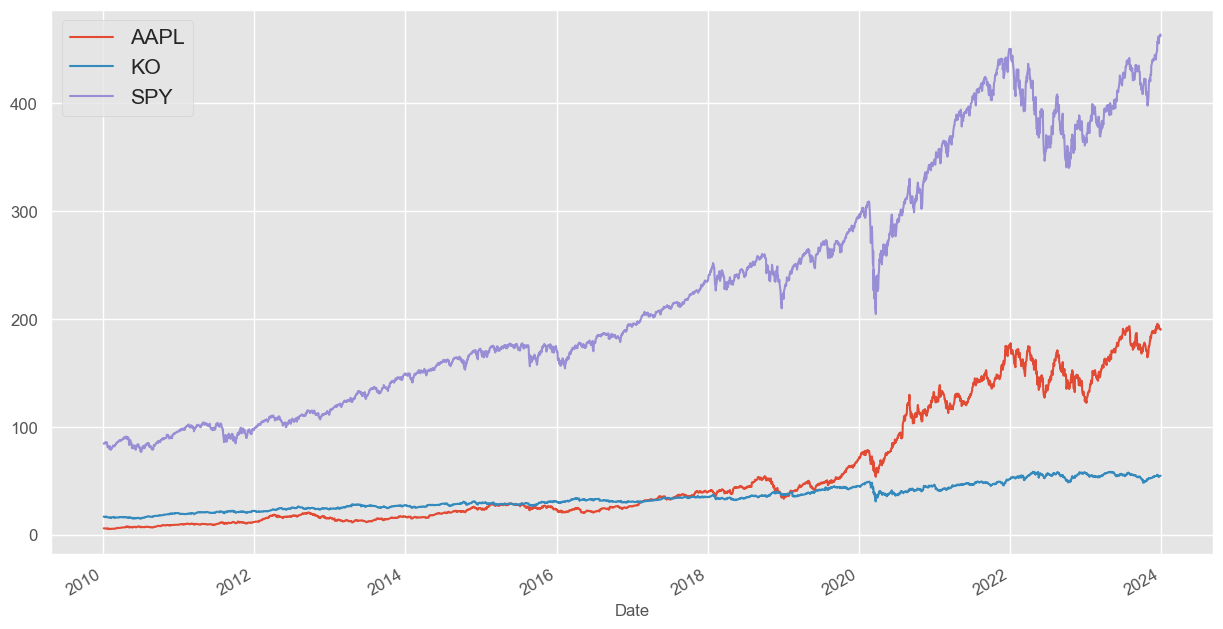

In [294]:
close.plot(figsize = (15,8), fontsize = 12) ## This creates a graph using the setup information above 

In [295]:
close.iloc[0,0] ## Will create the normalize point of the close data

np.float64(6.406480312347412)

In [296]:
close.AAPL.div(close.iloc[0,0]) ## Dividing all the close apple values by the normalize point

Date
2010-01-04     1.000000
2010-01-05     1.001729
2010-01-06     0.985795
2010-01-07     0.983973
2010-01-08     0.990515
                ...    
2023-12-22    29.881164
2023-12-26    29.796278
2023-12-27    29.811707
2023-12-28    29.878082
2023-12-29    29.716014
Name: AAPL, Length: 3522, dtype: float64

In [297]:
close.AAPL.div(close.iloc[0,0]).mul(100) ## Same as above just multiplied by 100 to make it seem neat

Date
2010-01-04     100.000000
2010-01-05     100.172894
2010-01-06      98.579510
2010-01-07      98.397260
2010-01-08      99.051458
                 ...     
2023-12-22    2988.116421
2023-12-26    2979.627778
2023-12-27    2981.170691
2023-12-28    2987.808219
2023-12-29    2971.601437
Name: AAPL, Length: 3522, dtype: float64

In [298]:
close.iloc[0] 

AAPL     6.406480
KO      17.316332
SPY     84.796364
Name: 2010-01-04 00:00:00, dtype: float64

In [299]:
close.div(close.iloc[0]).mul(100) ## This and the line above is just a simplier way of doing it 

,AAPL,KO,SPY
Date,,,
2010-01-04,100.000000,100.000000,100.000000
2010-01-05,100.172894,98.790328,100.264719
2010-01-06,98.579510,98.755246,100.335285
2010-01-07,98.397260,98.509805,100.758878
2010-01-08,99.051458,96.686557,101.094172
...,...,...,...
2023-12-22,2988.116421,315.277056,543.613424
2023-12-26,2979.627778,316.574482,545.908854
2023-12-27,2981.170691,317.385388,546.895931


In [300]:
normclose = close.div(close.iloc[0].mul(100))

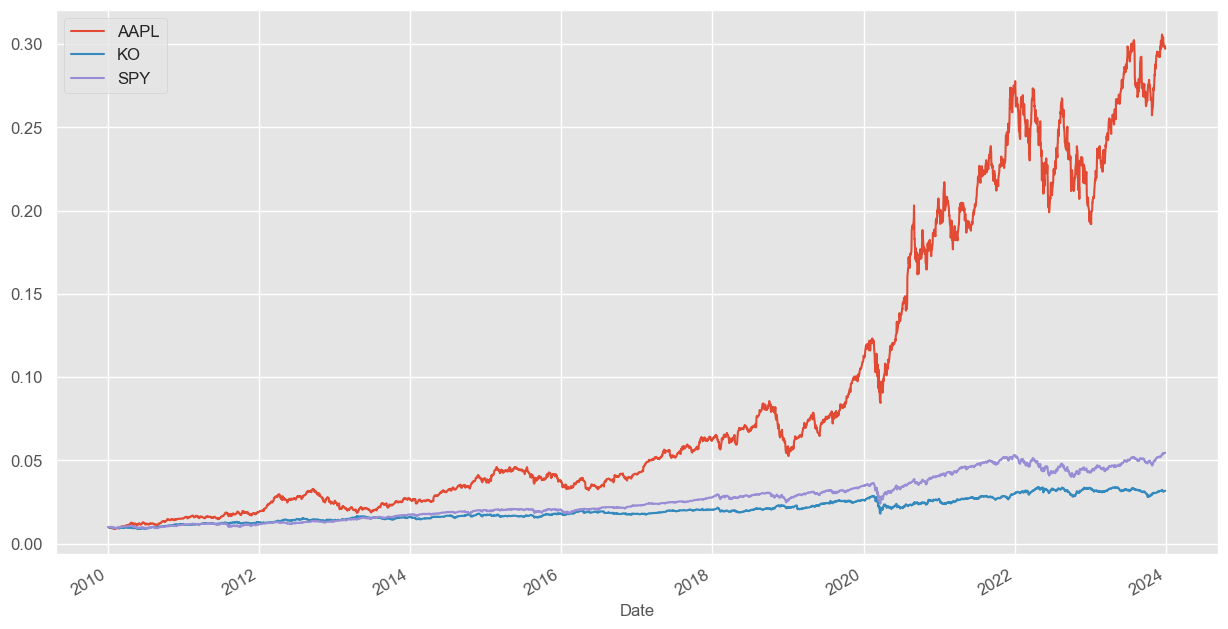

In [301]:
normclose.plot(figsize = (15,8), fontsize = 12) ## Using the normalized values, we can make a graph will all the values at the same starting point
plt.legend(fontsize = 12)
plt.show()

In [302]:
aapl = close.AAPL.copy().to_frame() ## Converts the close apple data to a dataframe 
aapl

,AAPL
Date,
2010-01-04,6.406480
2010-01-05,6.417557
2010-01-06,6.315477
2010-01-07,6.303801
2010-01-08,6.345712
...,...
2023-12-22,191.433090
2023-12-26,190.889267
2023-12-27,190.988113


In [303]:
aapl.shift(periods = 1) ## Shifts all the data down one spot from the close dataframe

,AAPL
Date,
2010-01-04,NaN
2010-01-05,6.406480
2010-01-06,6.417557
2010-01-07,6.315477
2010-01-08,6.303801
...,...
2023-12-22,192.500977
2023-12-26,191.433090
2023-12-27,190.889267


In [304]:
aapl["lag1"] = aapl.shift(periods = 1) ## Creates new column called lag1, used to calculate precentage change of daily returns    
aapl

,AAPL,lag1
Date,,
2010-01-04,6.406480,NaN
2010-01-05,6.417557,6.406480
2010-01-06,6.315477,6.417557
2010-01-07,6.303801,6.315477
2010-01-08,6.345712,6.303801
...,...,...
2023-12-22,191.433090,192.500977
2023-12-26,190.889267,191.433090
2023-12-27,190.988113,190.889267


In [305]:
aapl.AAPL.sub(aapl.lag1) ## Subrtacted data of AAPL - lag1 

Date
2010-01-04         NaN
2010-01-05    0.011076
2010-01-06   -0.102080
2010-01-07   -0.011676
2010-01-08    0.041911
                ...   
2023-12-22   -1.067886
2023-12-26   -0.543823
2023-12-27    0.098846
2023-12-28    0.425232
2023-12-29   -1.038284
Length: 3522, dtype: float64

In [306]:
aapl["diff"] = aapl.AAPL.sub(aapl.lag1) ## Adds the subtracted datd from above to the dataframe
aapl

,AAPL,lag1,diff
Date,,,
2010-01-04,6.406480,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076
2010-01-06,6.315477,6.417557,-0.102080
2010-01-07,6.303801,6.315477,-0.011676
2010-01-08,6.345712,6.303801,0.041911
...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886
2023-12-26,190.889267,191.433090,-0.543823
2023-12-27,190.988113,190.889267,0.098846


In [307]:
aapl.AAPL.div(aapl.lag1) ## Divides the close values from the lag1 values to get the precent change values 

Date
2010-01-04         NaN
2010-01-05    1.001729
2010-01-06    0.984094
2010-01-07    0.998151
2010-01-08    1.006649
                ...   
2023-12-22    0.994453
2023-12-26    0.997159
2023-12-27    1.000518
2023-12-28    1.002226
2023-12-29    0.994576
Length: 3522, dtype: float64

In [308]:
aapl["% Change"] = aapl.AAPL.div(aapl.lag1).sub(1).mul(100) ## Adds the precent change values to the dataframe 
aapl

,AAPL,lag1,diff,% Change
Date,,,,
2010-01-04,6.406480,NaN,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076,0.172894
2010-01-06,6.315477,6.417557,-0.102080,-1.590634
2010-01-07,6.303801,6.315477,-0.011676,-0.184877
2010-01-08,6.345712,6.303801,0.041911,0.664855
...,...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886,-0.554743
2023-12-26,190.889267,191.433090,-0.543823,-0.284080
2023-12-27,190.988113,190.889267,0.098846,0.051782


### If we wanted to combine the previous couple lines of code, we can just use code below 

In [309]:
aapl["diff2"] = aapl.AAPL.diff(periods = 1) ## This creates column diff 2, which is the same as diff 
aapl

,AAPL,lag1,diff,% Change,diff2
Date,,,,,
2010-01-04,6.406480,NaN,NaN,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076,0.172894,0.011076
2010-01-06,6.315477,6.417557,-0.102080,-1.590634,-0.102080
2010-01-07,6.303801,6.315477,-0.011676,-0.184877,-0.011676
2010-01-08,6.345712,6.303801,0.041911,0.664855,0.041911
...,...,...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886,-0.554743,-1.067886
2023-12-26,190.889267,191.433090,-0.543823,-0.284080,-0.543823
2023-12-27,190.988113,190.889267,0.098846,0.051782,0.098846


In [310]:
aapl["% Change2"] = aapl.AAPL.pct_change(periods = 1).mul(100) ## This is a shortcut to get to the precent change, notice how % Chnage = % Change2
aapl

,AAPL,lag1,diff,% Change,diff2,% Change2
Date,,,,,,
2010-01-04,6.406480,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076,0.172894,0.011076,0.172894
2010-01-06,6.315477,6.417557,-0.102080,-1.590634,-0.102080,-1.590634
2010-01-07,6.303801,6.315477,-0.011676,-0.184877,-0.011676,-0.184877
2010-01-08,6.345712,6.303801,0.041911,0.664855,0.041911,0.664855
...,...,...,...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886,-0.554743,-1.067886,-0.554743
2023-12-26,190.889267,191.433090,-0.543823,-0.284080,-0.543823,-0.284080
2023-12-27,190.988113,190.889267,0.098846,0.051782,0.098846,0.051782


In [311]:
aapl = aapl.drop(columns=['diff2'], errors='ignore') ## This is math research code, can be used for multiple columns as well
aapl

,AAPL,lag1,diff,% Change,% Change2
Date,,,,,
2010-01-04,6.406480,NaN,NaN,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076,0.172894,0.172894
2010-01-06,6.315477,6.417557,-0.102080,-1.590634,-1.590634
2010-01-07,6.303801,6.315477,-0.011676,-0.184877,-0.184877
2010-01-08,6.345712,6.303801,0.041911,0.664855,0.664855
...,...,...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886,-0.554743,-0.554743
2023-12-26,190.889267,191.433090,-0.543823,-0.284080,-0.284080
2023-12-27,190.988113,190.889267,0.098846,0.051782,0.051782


In [312]:
aapl.rename(columns = {"% Change2":"Daily Change"}, inplace = True) ## Changes the name of % Change 2 ---> Daily Change 
aapl

,AAPL,lag1,diff,% Change,Daily Change
Date,,,,,
2010-01-04,6.406480,NaN,NaN,NaN,NaN
2010-01-05,6.417557,6.406480,0.011076,0.172894,0.172894
2010-01-06,6.315477,6.417557,-0.102080,-1.590634,-1.590634
2010-01-07,6.303801,6.315477,-0.011676,-0.184877,-0.184877
2010-01-08,6.345712,6.303801,0.041911,0.664855,0.664855
...,...,...,...,...,...
2023-12-22,191.433090,192.500977,-1.067886,-0.554743,-0.554743
2023-12-26,190.889267,191.433090,-0.543823,-0.284080,-0.284080
2023-12-27,190.988113,190.889267,0.098846,0.051782,0.051782


In [313]:
aapl.AAPL.resample("ME").last() ## Gives data of the last day of the month now, good for montly returns 

Date
2010-01-31      5.749398
2010-02-28      6.125388
2010-03-31      7.034823
2010-04-30      7.815841
2010-05-31      7.689810
                 ...    
2023-08-31    185.522797
2023-09-30    169.070969
2023-10-31    168.636459
2023-11-30    187.823975
2023-12-31    190.375061
Freq: ME, Name: AAPL, Length: 168, dtype: float64

In [314]:
aapl.AAPL.resample("BME").last() ## Gives the last business day of the month, cuts out Saturdays and Sundays 

Date
2010-01-29      5.749398
2010-02-26      6.125388
2010-03-31      7.034823
2010-04-30      7.815841
2010-05-31      7.689810
                 ...    
2023-08-31    185.522797
2023-09-29    169.070969
2023-10-31    168.636459
2023-11-30    187.823975
2023-12-29    190.375061
Freq: BME, Name: AAPL, Length: 168, dtype: float64

In [315]:
aapl.AAPL.resample("BME").last().pct_change(periods = 1).mul(100) ## Precentage change of the last day of the month for AAPl stock

Date
2010-01-29          NaN
2010-02-26     6.539631
2010-03-31    14.846983
2010-04-30    11.102174
2010-05-31    -1.612506
                ...    
2023-08-31    -4.238387
2023-09-29    -8.867820
2023-10-31    -0.256998
2023-11-30    11.378035
2023-12-29     1.358233
Freq: BME, Name: AAPL, Length: 168, dtype: float64

In [316]:
aapl = aapl.drop(columns=['diff2', 'diff', 'lag1', '% Change', 'Daily Change'], errors='ignore')
aapl

,AAPL
Date,
2010-01-04,6.406480
2010-01-05,6.417557
2010-01-06,6.315477
2010-01-07,6.303801
2010-01-08,6.345712
...,...
2023-12-22,191.433090
2023-12-26,190.889267
2023-12-27,190.988113


In [317]:
ret = aapl.pct_change().dropna() ## Gives the daily return or precent change of the AAPL data 
ret

,AAPL
Date,
2010-01-05,0.001729
2010-01-06,-0.015906
2010-01-07,-0.001849
2010-01-08,0.006649
2010-01-11,-0.008822
...,...
2023-12-22,-0.005547
2023-12-26,-0.002841
2023-12-27,0.000518


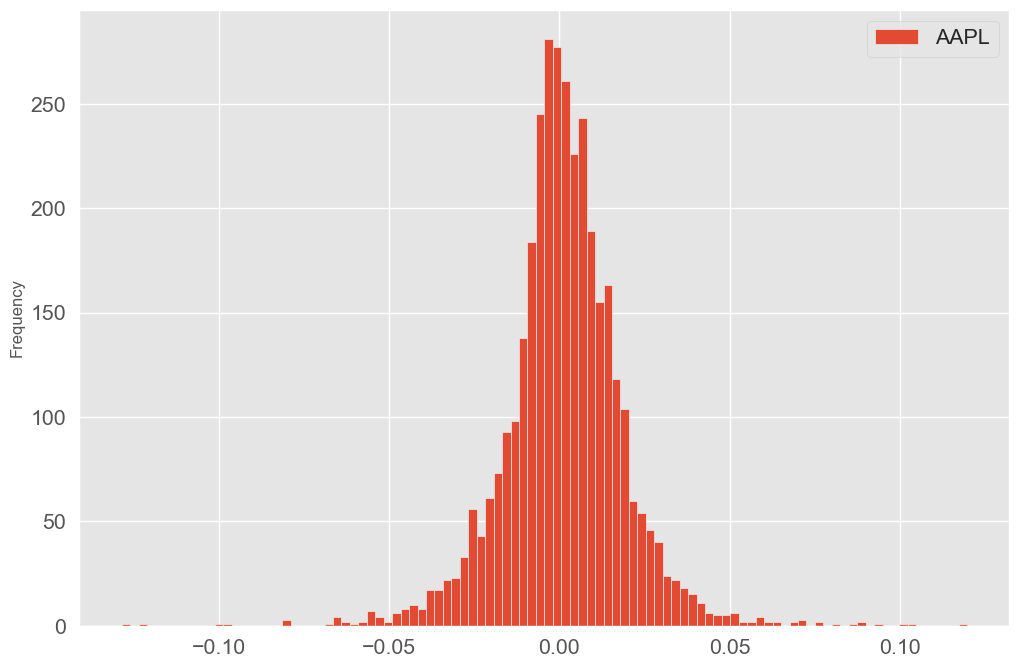

In [318]:
ret.plot(kind = "hist", figsize = (12,8), bins = 100) ## Creates a histogram of the daily precent change of the AAPl data 

plt.show()

In [319]:
daily_mean_ret = ret.mean() ## Calculates the average daily returns  
daily_mean_ret

AAPL    0.001122
dtype: float64

In [320]:
var_daily = ret.var() ## Calulates the variance in the daily returns
var_daily

AAPL    0.000316
dtype: float64

In [321]:
std_daily = np.sqrt(var_daily) ## Calculates the standard deviation in the daily returns 
std_daily 

AAPL    0.017764
dtype: float64

In [322]:
ret.std() ## Same as code above, just done quicker 

AAPL    0.017764
dtype: float64

In [323]:
annual_mean_ret = daily_mean_ret*252 ## The yearly average return for AAPL
annual_mean_ret

AAPL    0.282645
dtype: float64

In [324]:
annual_var_return = var_daily*252 ## The yearly varaince of the return
annual_var_return

AAPL    0.079524
dtype: float64

In [325]:
annual_std_return = np.sqrt(annual_var_return) ## The yearly standard deviation of the returns
annual_std_return

AAPL    0.282001
dtype: float64

In [326]:
ret.std()*np.sqrt(252) ## Same as the code above, just done quicker 

AAPL    0.282001
dtype: float64

In [327]:
ticker = ["SPY", "AAPL", "KO", "IBM", "DIS", "MSFT"]

In [328]:
stocks = yf.download(ticker, start = "2010-01-01", end = "2022-01-01")

[*********************100%***********************]  6 of 6 completed


In [329]:
close = stocks.loc[:,"Close"].copy() ## Made a copy of all the close data of the slected data 

<function matplotlib.pyplot.show(close=None, block=None)>

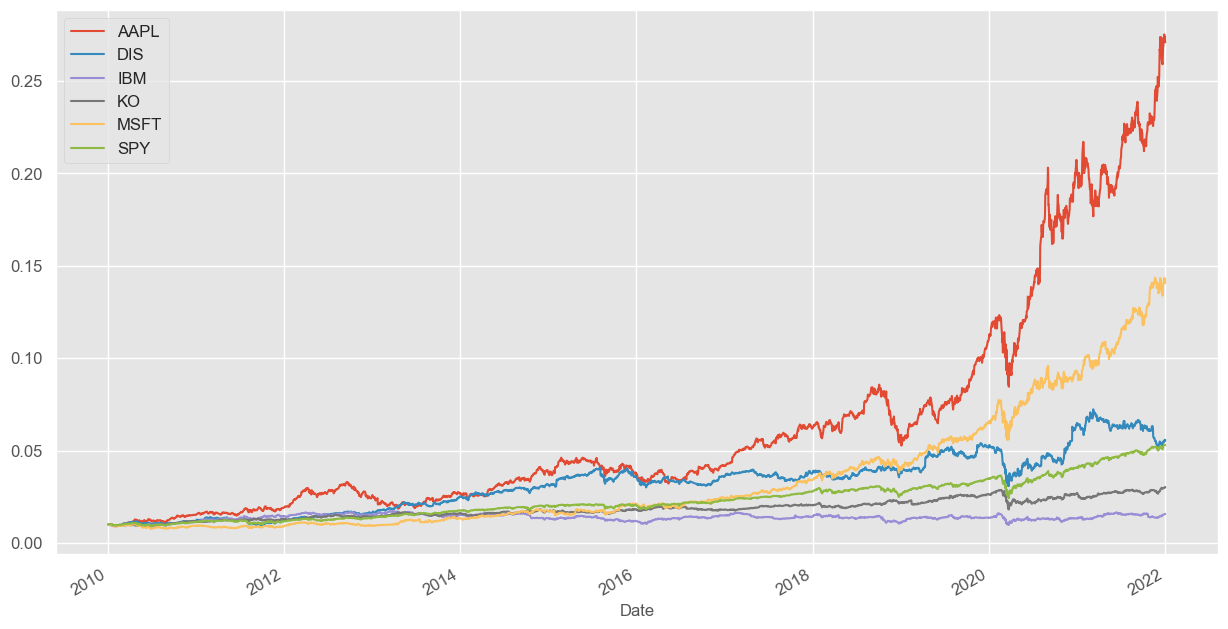

In [330]:
normclose = close.div(close.iloc[0].mul(100)) ## Normalize all the close data selections 

normclose.plot(figsize = (15,8), fontsize = 12) ## Make the graph of all the selected data normalized 
plt.legend(fontsize = 12)
plt.show

In [331]:
ret = close.pct_change().dropna() ## All the head data for the precent change 
ret.head()

Ticker,AAPL,DIS,IBM,KO,MSFT,SPY
Date,,,,,,
2010-01-05,0.001729,-0.002495,-0.012080,-0.012097,0.000323,0.002647
2010-01-06,-0.015906,-0.005314,-0.006496,-0.000355,-0.006137,0.000704
2010-01-07,-0.001849,0.000314,-0.003462,-0.002485,-0.010400,0.004221
2010-01-08,0.006648,0.001571,0.010035,-0.018509,0.006897,0.003328
2010-01-11,-0.008821,-0.016311,-0.010470,0.020309,-0.012720,0.001396


In [332]:
ret.describe().T ## Important values for each ticker value (.T) is only for stylr of matrix 

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,3020.0,0.001249,0.017669,-0.128647,-0.007021,0.000999,0.010503,0.119808
DIS,3020.0,0.000690,0.015698,-0.129846,-0.006337,0.000595,0.007778,0.144123
IBM,3020.0,0.000249,0.014115,-0.128507,-0.006126,0.000397,0.006974,0.113010
KO,3020.0,0.000425,0.010937,-0.096725,-0.004493,0.000496,0.005762,0.064796
MSFT,3020.0,0.001000,0.015783,-0.147390,-0.006642,0.000694,0.008788,0.142169
SPY,3020.0,0.000609,0.010671,-0.109424,-0.003416,0.000729,0.005517,0.090603


In [333]:
summary = ret.describe().T.loc[:,["mean", "std"]] ## Singles out coulmns of this dataframe made above 
summary

,mean,std
Ticker,,
AAPL,0.001249,0.017669
DIS,0.000690,0.015698
IBM,0.000249,0.014115
KO,0.000425,0.010937
MSFT,0.001000,0.015783
SPY,0.000609,0.010671


In [334]:
summary["mean"] = summary["mean"]*252 ## We get the annualized mean from these stocks 
summary["std"] = summary["std"]*np.sqrt(252) ## We get the annualized standard deviation from these stocks
summary

,mean,std
Ticker,,
AAPL,0.314838,0.280479
DIS,0.173903,0.249206
IBM,0.062691,0.224068
KO,0.107212,0.173621
MSFT,0.252102,0.250550
SPY,0.153353,0.169397


Text(0.5, 1.0, 'Annual Risk/Return')

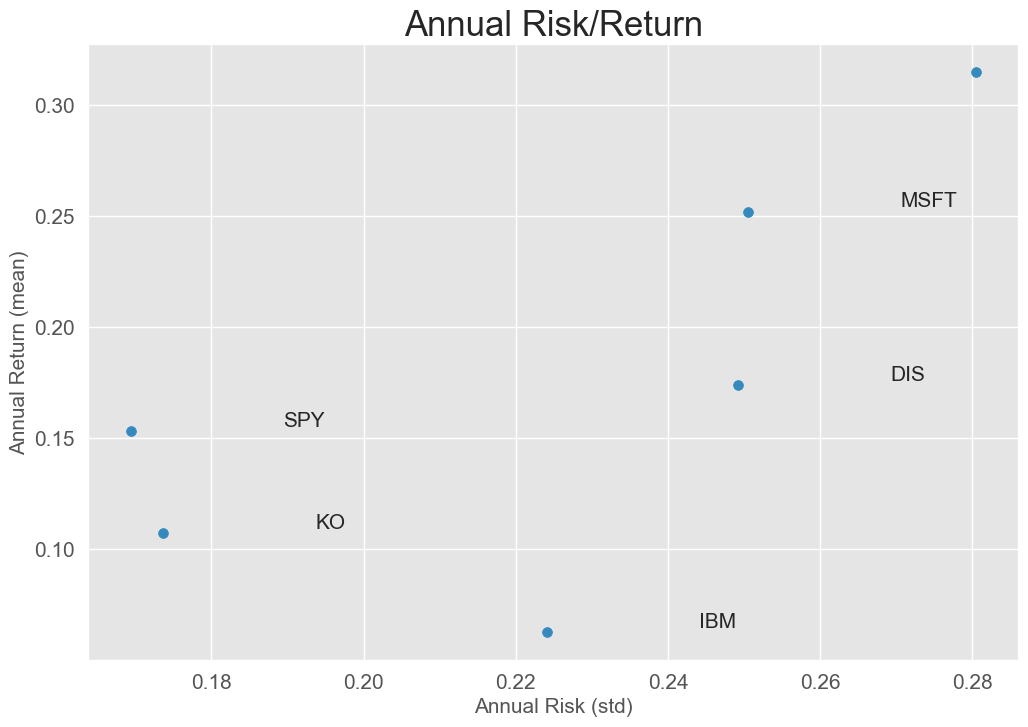

In [335]:
summary.plot.scatter(x = "std", y = "mean", figsize = (12,8), s = 50, fontsize = 15) ## This just makes the scatter plot without any labels 

for i in summary.index: ## Adds the Letters next to the specifc data points that in the scatter plot 
    plt.annotate(i,xy = (summary.loc[i, "std"] + 0.02, summary.loc[i, "mean"] + 0.002), size = 15)
plt.xlabel("Annual Risk (std)", fontsize = 15) ## Adds the labels and determines their font size 
plt.ylabel("Annual Return (mean)", fontsize = 15)
plt.title("Annual Risk/Return", fontsize = 25)

### The graph above is used to elvaluate how risky a stock is and which ones has the best returns, important for back testing

# Correlation and Covariance 

In [336]:
ret

Ticker,AAPL,DIS,IBM,KO,MSFT,SPY
Date,,,,,,
2010-01-05,0.001729,-0.002495,-0.012080,-0.012097,0.000323,0.002647
2010-01-06,-0.015906,-0.005314,-0.006496,-0.000355,-0.006137,0.000704
2010-01-07,-0.001849,0.000314,-0.003462,-0.002485,-0.010400,0.004221
2010-01-08,0.006648,0.001571,0.010035,-0.018509,0.006897,0.003328
2010-01-11,-0.008821,-0.016311,-0.010470,0.020309,-0.012720,0.001396
...,...,...,...,...,...,...
2021-12-27,0.022975,-0.005403,0.007579,0.007386,0.023186,0.014152
2021-12-28,-0.005767,0.015707,0.007673,0.003922,-0.003504,-0.000817
2021-12-29,0.000502,-0.002126,0.005429,0.001189,0.002051,0.001279


In [337]:
ret.cov() ## You get the covatriance of all the stocks 

Ticker,AAPL,DIS,IBM,KO,MSFT,SPY
Ticker,,,,,,
AAPL,0.000312,0.000108,0.000102,0.000066,0.000157,0.000124
DIS,0.000108,0.000246,0.000105,0.000082,0.000114,0.000116
IBM,0.000102,0.000105,0.000199,0.000076,0.000110,0.000102
KO,0.000066,0.000082,0.000076,0.000120,0.000074,0.000074
MSFT,0.000157,0.000114,0.000110,0.000074,0.000249,0.000125
SPY,0.000124,0.000116,0.000102,0.000074,0.000125,0.000114


In [338]:
ret.corr() ## You get the correlation of all the stocks, notice how the same stocks have a 1.00 correlation 

Ticker,AAPL,DIS,IBM,KO,MSFT,SPY
Ticker,,,,,,
AAPL,1.000000,0.388693,0.407134,0.339150,0.564250,0.660223
DIS,0.388693,1.000000,0.474053,0.479168,0.459500,0.690421
IBM,0.407134,0.474053,1.000000,0.493315,0.495662,0.676240
KO,0.339150,0.479168,0.493315,1.000000,0.430416,0.635960
MSFT,0.564250,0.459500,0.495662,0.430416,1.000000,0.744913
SPY,0.660223,0.690421,0.676240,0.635960,0.744913,1.000000


In [339]:
import seaborn as sns

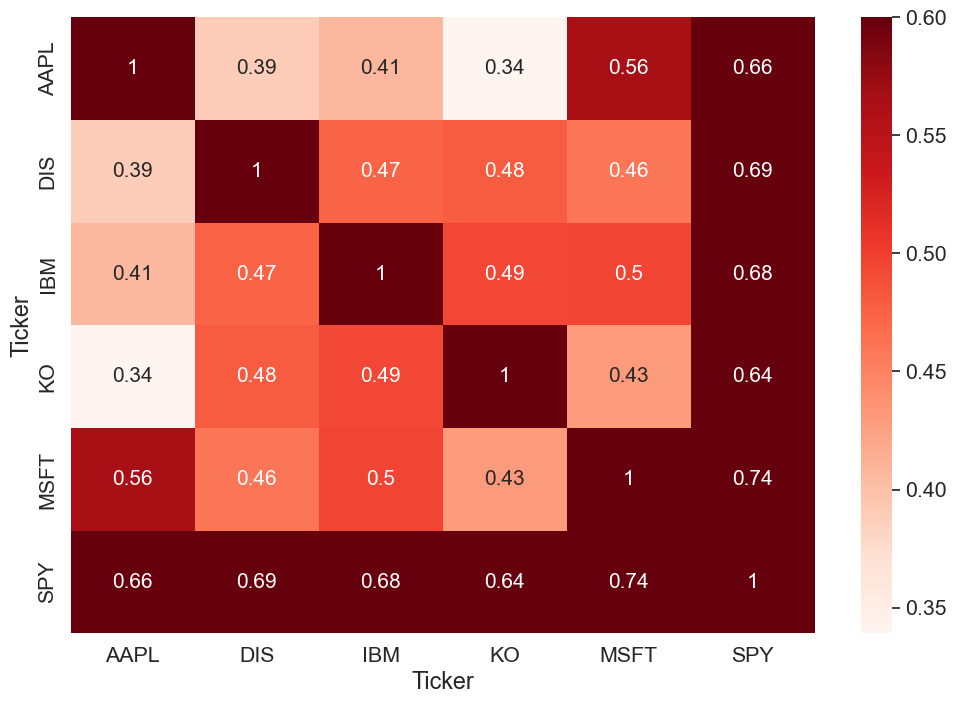

In [340]:
plt.figure(figsize = (12,8)) ## This block of code is used to see what stocks are related to one another and 
sns.set(font_scale = 1.4)
sns.heatmap(ret.corr(), cmap="Reds", annot = True, annot_kws = {"size": 15}, vmax = 0.6)
plt.show()

# Simple Returns and Log Returns 

In [341]:
df = pd.DataFrame(index = [2016, 2017, 2018], data = [100, 50, 95], columns = ["Price"]) # Created random DataFrame 
df 

,Price
2016,100
2017,50
2018,95


In [342]:
simplereturns = df.pct_change().dropna() ## Calculates the simple returns of the dataframe
simplereturns 

,Price
2017,-0.5
2018,0.9


In [343]:
simplereturns.mean() ## Calculates the simple returns of the dataframe

Price    0.2
dtype: float64

### Note that mean returns are misleading when predicting 

In [344]:
logreturns = np.log(df/df.shift(1)).dropna() ## Calculates the log returns of the dataframe of your selection 
logreturns

,Price
2017,-0.693147
2018,0.641854


In [345]:
logreturns.mean() ## Mean of the log returns 

Price   -0.025647
dtype: float64

In [346]:
100*np.exp(logreturns.mean()*2) ## Calcluated the expected return using the log returns, much more accurate for this data

Price    95.0
dtype: float64

In [347]:
SPY = yf.download("SPY", period = "max") ## Just gives all the SPY data that is avaiable in yfinance 
SPY

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
1993-01-29,24.175392,24.192587,24.072225,24.192587,1003200
1993-02-01,24.347324,24.347324,24.192574,24.192574,480500
1993-02-02,24.398909,24.416103,24.278548,24.330131,201300
1993-02-03,24.656830,24.674024,24.416108,24.433302,529400
1993-02-04,24.759998,24.811582,24.467693,24.742804,531500
...,...,...,...,...,...
2026-06-01,758.539978,760.280029,754.690002,755.359985,43634900
2026-06-02,759.570007,760.400024,756.750000,757.030029,31581900


In [348]:
spy = SPY[["Close"]].copy()  
spy["SMA50"] = spy["Close"].rolling(window=50, min_periods=50).mean()
spy["SMA200"] = spy["Close"].rolling(window = 200, min_periods = 200).mean()
spy

Price,Close,SMA50,SMA200
Ticker,SPY,,
Date,,,
1993-01-29,24.175392,NaN,NaN
1993-02-01,24.347324,NaN,NaN
1993-02-02,24.398909,NaN,NaN
1993-02-03,24.656830,NaN,NaN
1993-02-04,24.759998,NaN,NaN
...,...,...,...
2026-06-01,758.539978,705.621801,679.271795
2026-06-02,759.570007,707.841801,679.872018


# Always make sure the code above is always in the same kernel, otherwise the newly made columns will juts become NaN
### This code makes a copy of the SPY Close column, turns it into a dataframe, and allows you to make the SMA  

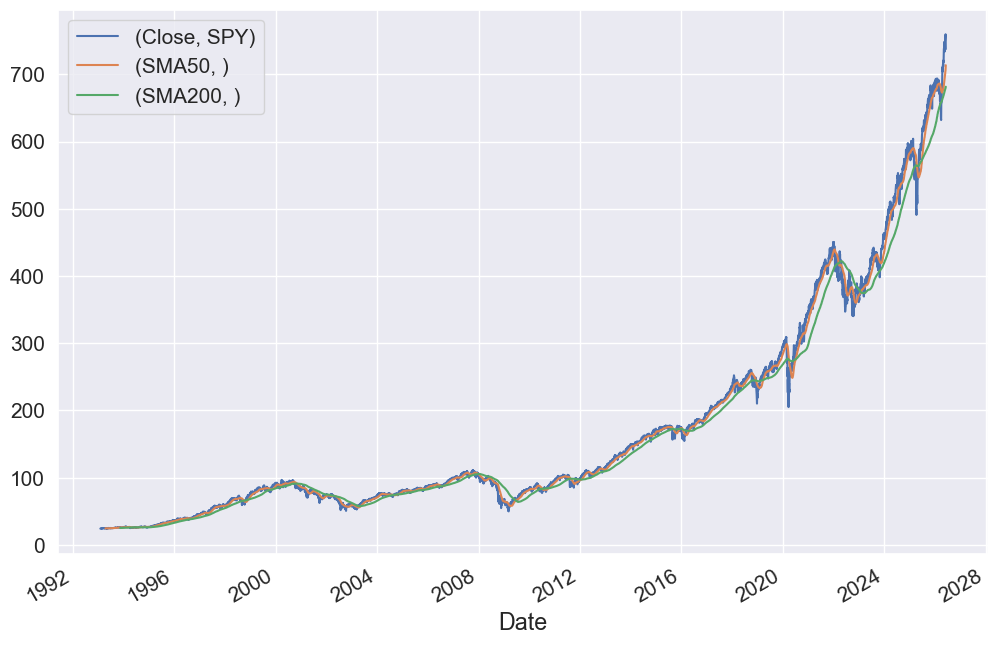

In [349]:
spy.plot(figsize = (12,8), fontsize = 15) ## General code for making a plot of some dataframe 
plt.legend(loc = "upper left", fontsize = 15)
plt.show()

### *This is the basis of where trading strategy comes from, we can see that from our previously recroded data that the market is usually closing above the 200 day moving average so its probaly best to go long in this case. This can vary for certian quarters and other economic factors, but generally this is the biggest indicator*

In [350]:
spy1 = SPY[["Close"]].copy()  ## Making the EMA column for some copy of the SYP closing data
spy1["EMA100"] = spy["Close"].ewm(span = 100, min_periods = 100).mean()
spy1

Price,Close,EMA100
Ticker,SPY,
Date,,
1993-01-29,24.175392,NaN
1993-02-01,24.347324,NaN
1993-02-02,24.398909,NaN
1993-02-03,24.656830,NaN
1993-02-04,24.759998,NaN
...,...,...
2026-06-01,758.539978,700.143405
2026-06-02,759.570007,701.320170


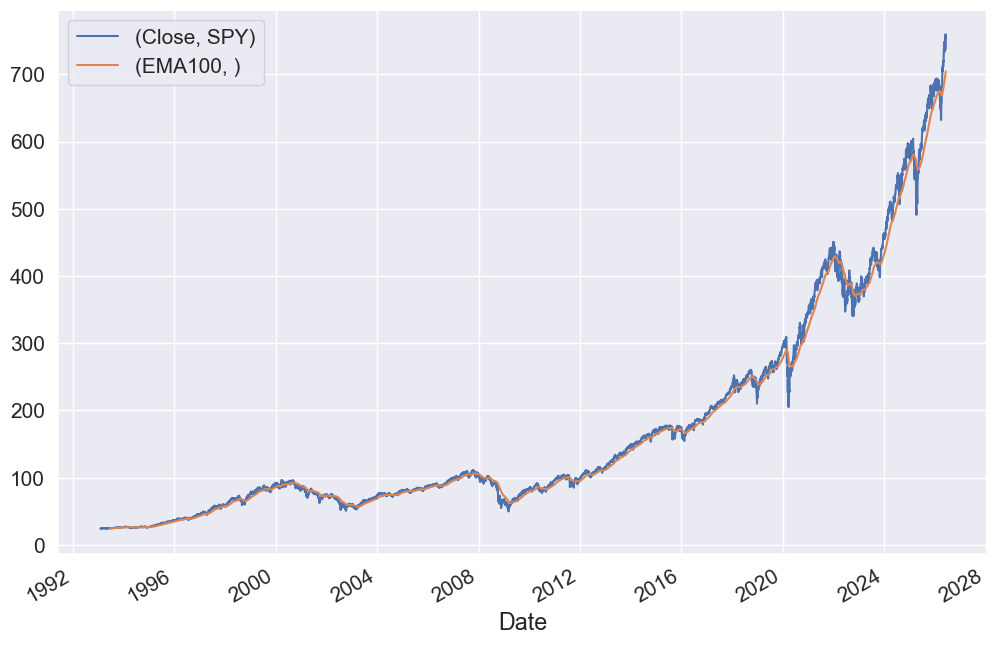

In [351]:
spy1.plot(figsize = (12,8), fontsize = 15) ## Plot for spy1
plt.legend(loc = "upper left", fontsize = 15)
plt.show()

In [352]:
spy["Day"] = spy.index.day_name() ## Will add the DOW and quarter for each data point 
spy["Quarter"] = spy.index.quarter
spy

Price,Close,SMA50,SMA200,Day,Quarter
Ticker,SPY,,,,
Date,,,,,
1993-01-29,24.175392,NaN,NaN,Friday,1
1993-02-01,24.347324,NaN,NaN,Monday,1
1993-02-02,24.398909,NaN,NaN,Tuesday,1
1993-02-03,24.656830,NaN,NaN,Wednesday,1
1993-02-04,24.759998,NaN,NaN,Thursday,1
...,...,...,...,...,...
2026-06-01,758.539978,705.621801,679.271795,Monday,2
2026-06-02,759.570007,707.841801,679.872018,Tuesday,2


In [353]:
SPY = yf.download("SPY", period = "max") ## Downloads all the SPY data 

[*********************100%***********************]  1 of 1 completed


In [354]:
spy = SPY[["Close"]].copy() ## Makes a data frame of the spy close data, as a copy of what was already created 
spy

Price,Close
Ticker,SPY
Date,
1993-01-29,24.175385
1993-02-01,24.347338
1993-02-02,24.398911
1993-02-03,24.656822
1993-02-04,24.759996
...,...
2026-06-01,758.539978
2026-06-02,759.570007


In [355]:
all_days = pd.date_range(start = "2010 - 12- 31", end = "2020 - 01- 01", freq = "D") ## Changes the date range to certian peroid along with data type 
all_days

DatetimeIndex(['2010-12-31', '2011-01-01', '2011-01-02', '2011-01-03',
               '2011-01-04', '2011-01-05', '2011-01-06', '2011-01-07',
               '2011-01-08', '2011-01-09',
               ...
               '2019-12-23', '2019-12-24', '2019-12-25', '2019-12-26',
               '2019-12-27', '2019-12-28', '2019-12-29', '2019-12-30',
               '2019-12-31', '2020-01-01'],
              dtype='datetime64[ns]', length=3289, freq='D')

In [356]:
spy

Price,Close
Ticker,SPY
Date,
1993-01-29,24.175385
1993-02-01,24.347338
1993-02-02,24.398911
1993-02-03,24.656822
1993-02-04,24.759996
...,...
2026-06-01,758.539978
2026-06-02,759.570007


In [357]:
spy = spy.reindex(all_days) ## Reindexed to have all the days for the spy data, including weekends  
spy

Price,Close
Ticker,SPY
2010-12-31,95.936394
2011-01-01,NaN
2011-01-02,NaN
2011-01-03,96.928177
2011-01-04,96.874779
...,...
2019-12-28,NaN
2019-12-29,NaN
2019-12-30,293.424622


In [358]:
spy.ffill() ## Fills the NaN values with the most previous closing price (friday)

Price,Close
Ticker,SPY
2010-12-31,95.936394
2011-01-01,95.936394
2011-01-02,95.936394
2011-01-03,96.928177
2011-01-04,96.874779
...,...
2019-12-28,295.051392
2019-12-29,295.051392
2019-12-30,293.424622


In [359]:
spy.bfill() ## Fills the NaN values with the next days closing price (monday)

Price,Close
Ticker,SPY
2010-12-31,95.936394
2011-01-01,96.928177
2011-01-02,96.928177
2011-01-03,96.928177
2011-01-04,96.874779
...,...
2019-12-28,293.424622
2019-12-29,293.424622
2019-12-30,293.424622


In [360]:
SPY = yf.download("SPY", interval = "1wk", period = "max") ## Use shift + tab to see what time intervals are valid 

[*********************100%***********************]  1 of 1 completed


In [361]:
SPY

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
1993-01-25,24.175377,24.192571,24.072210,24.192571,1003200
1993-02-01,24.742796,24.811574,24.192574,24.192574,2234800
1993-02-08,24.536476,24.828782,24.502087,24.742810,1159800
1993-02-15,23.969057,24.467696,23.556390,24.467696,998700
1993-02-22,24.433283,24.450477,23.917450,24.037811,1024300
...,...,...,...,...,...
2026-05-04,737.619995,738.080017,714.989990,720.070007,241124400
2026-05-11,739.169983,749.530029,731.830017,736.450012,248127900


## Cummaltive Returns, Drawdowns etc. 

In [362]:
apple = yf.download("AAPL", period = "max") ## Creating the apple data frame 
apple

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1980-12-12,0.098207,0.098634,0.098207,0.098207,469033600
1980-12-15,0.093083,0.093510,0.093083,0.093510,175884800
1980-12-16,0.086251,0.086678,0.086251,0.086678,105728000
1980-12-17,0.088386,0.088813,0.088386,0.088386,86441600
1980-12-18,0.090949,0.091376,0.090949,0.090949,73449600
...,...,...,...,...,...
2026-06-01,306.309998,310.940002,305.019989,309.630005,48849900
2026-06-02,315.200012,315.450012,306.690002,307.459991,44534700


In [363]:
apple = apple[["Close"]].copy() ## Making a copy of the apple close data 
apple

Price,Close
Ticker,AAPL
Date,
1980-12-12,0.098207
1980-12-15,0.093083
1980-12-16,0.086251
1980-12-17,0.088386
1980-12-18,0.090949
...,...
2026-06-01,306.309998
2026-06-02,315.200012


In [364]:
apple["d_returns"] = np.log(apple["Close"] / apple["Close"].shift(1)).values ## Creates a new column for the close dataframe, needs .values to work 
apple

Price,Close,d_returns
Ticker,AAPL,
Date,,
1980-12-12,0.098207,NaN
1980-12-15,0.093083,-0.053581
1980-12-16,0.086251,-0.076231
1980-12-17,0.088386,0.024450
1980-12-18,0.090949,0.028580
...,...,...
2026-06-01,306.309998,-0.018598
2026-06-02,315.200012,0.028610


In [365]:
apple.dropna(inplace = True) ## Gets rid of the NaN value in the top row 
apple 

Price,Close,d_returns
Ticker,AAPL,
Date,,
1980-12-15,0.093083,-0.053581
1980-12-16,0.086251,-0.076231
1980-12-17,0.088386,0.024450
1980-12-18,0.090949,0.028580
1980-12-19,0.096499,0.059239
...,...,...
2026-06-01,306.309998,-0.018598
2026-06-02,315.200012,0.028610


In [366]:
apple.d_returns.sum() ## Sum of the returns 

np.float64(8.048632125699399)

In [367]:
np.exp(apple.d_returns.sum()) ## How much you would have made if you invested $1 on 12/15/80 

np.float64(3129.511264138036)

In [368]:
apple["cummreturns"] = apple.d_returns.cumsum().apply(np.exp) ## The Cummreturns are how much you would make if you invested $1 on 12/15/80
apple

Price,Close,d_returns,cummreturns
Ticker,AAPL,,
Date,,,
1980-12-15,0.093083,-0.053581,0.947829
1980-12-16,0.086251,-0.076231,0.878261
1980-12-17,0.088386,0.024450,0.899999
1980-12-18,0.090949,0.028580,0.926091
1980-12-19,0.096499,0.059239,0.982610
...,...,...,...
2026-06-01,306.309998,-0.018598,3119.023229
2026-06-02,315.200012,0.028610,3209.546432


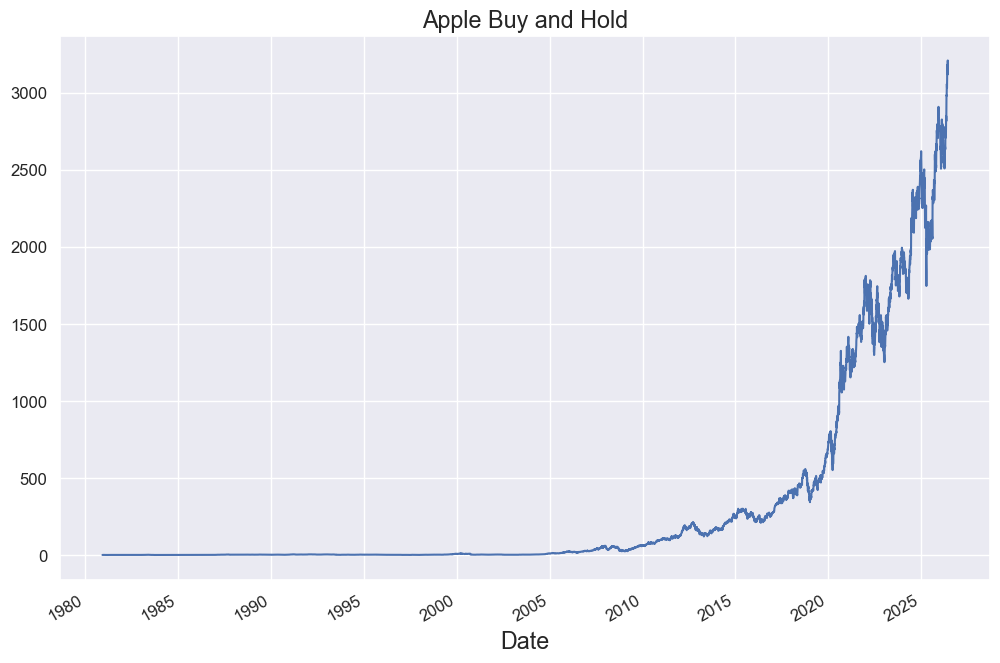

In [369]:
apple.cummreturns.plot(figsize = (12,8), title = "Apple Buy and Hold", fontsize = 12)
plt.show()

In [370]:
apple.d_returns.mean()*252 ## Annual Mean Return

np.float64(0.17697018547039947)

In [371]:
apple.d_returns.std()*np.sqrt(252) ## Annual Std Return 

np.float64(0.4437858725421266)

#### How to calculate Drawdowns 

In [372]:
apple["Cummmax"] = apple.cummreturns.cummax()
apple

Price,Close,d_returns,cummreturns,Cummmax
Ticker,AAPL,,,
Date,,,,
1980-12-15,0.093083,-0.053581,0.947829,0.947829
1980-12-16,0.086251,-0.076231,0.878261,0.947829
1980-12-17,0.088386,0.024450,0.899999,0.947829
1980-12-18,0.090949,0.028580,0.926091,0.947829
1980-12-19,0.096499,0.059239,0.982610,0.982610
...,...,...,...,...
2026-06-01,306.309998,-0.018598,3119.023229,3182.155292
2026-06-02,315.200012,0.028610,3209.546432,3209.546432


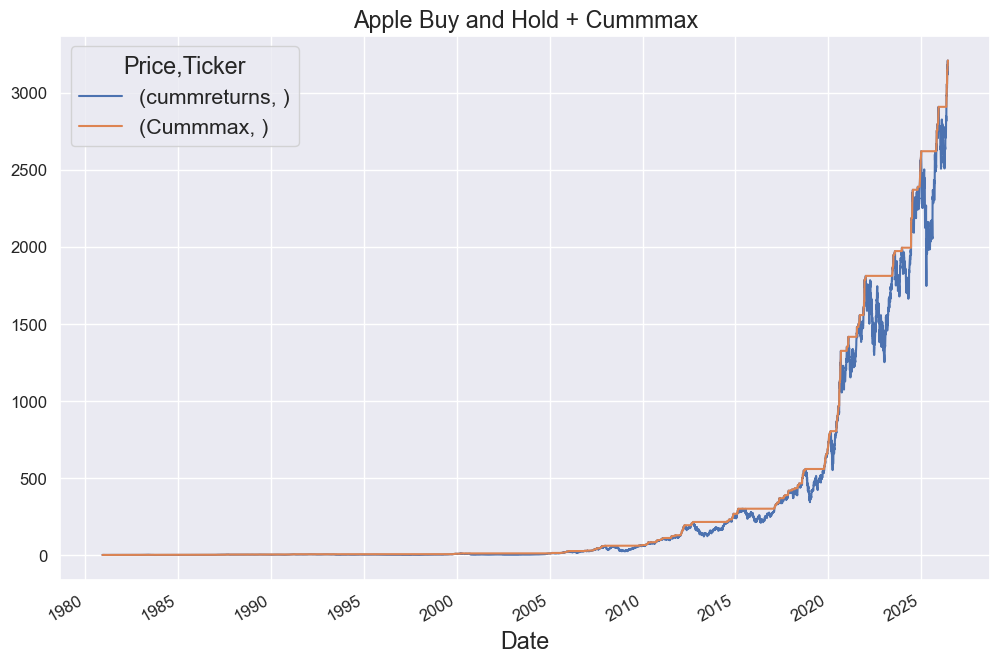

In [374]:
apple[["cummreturns", "Cummmax"]].plot(figsize = (12,8), title = "Apple Buy and Hold + Cummmax", fontsize = 12)
plt.show()

In [376]:
apple["drawdown"] = apple["Cummmax"] - apple["cummreturns"] ## Calculating the apple drawdowns 
apple

Price,Close,d_returns,cummreturns,Cummmax,drawdown
Ticker,AAPL,,,,
Date,,,,,
1980-12-15,0.093083,-0.053581,0.947829,0.947829,0.000000
1980-12-16,0.086251,-0.076231,0.878261,0.947829,0.069568
1980-12-17,0.088386,0.024450,0.899999,0.947829,0.047831
1980-12-18,0.090949,0.028580,0.926091,0.947829,0.021738
1980-12-19,0.096499,0.059239,0.982610,0.982610,0.000000
...,...,...,...,...,...
2026-06-01,306.309998,-0.018598,3119.023229,3182.155292,63.132063
2026-06-02,315.200012,0.028610,3209.546432,3209.546432,0.000000


In [377]:
apple.drawdown.max() ## The max drawdown apple has had 

874.2940222700256

In [378]:
apple.drawdown.idxmax() ## Date of this max drawdown 

Timestamp('2025-04-08 00:00:00')

In [379]:
apple.loc[(apple.index == "2025-04-08")]

Price,Close,d_returns,cummreturns,Cummmax,drawdown
Ticker,AAPL,,,,
Date,,,,,
2025-04-08,171.513763,-0.051102,1746.451035,2620.745057,874.294022


In [380]:
apple.loc[(apple.index <= "2025-04-08")]

Price,Close,d_returns,cummreturns,Cummmax,drawdown
Ticker,AAPL,,,,
Date,,,,,
1980-12-15,0.093083,-0.053581,0.947829,0.947829,0.000000
1980-12-16,0.086251,-0.076231,0.878261,0.947829,0.069568
1980-12-17,0.088386,0.024450,0.899999,0.947829,0.047831
1980-12-18,0.090949,0.028580,0.926091,0.947829,0.021738
1980-12-19,0.096499,0.059239,0.982610,0.982610,0.000000
...,...,...,...,...,...
2025-04-02,222.713242,0.003131,2267.793344,2620.745057,352.951712
2025-04-03,202.122025,-0.097013,2058.121820,2620.745057,562.623237


In [382]:
apple["drawdown%"] = (apple["Cummmax"] - apple["cummreturns"])/apple["Cummmax"] ## Creates drawdown precentage column 
apple

Price,Close,d_returns,cummreturns,Cummmax,drawdown,drawdown%
Ticker,AAPL,,,,,
Date,,,,,,
1980-12-15,0.093083,-0.053581,0.947829,0.947829,0.000000,0.000000
1980-12-16,0.086251,-0.076231,0.878261,0.947829,0.069568,0.073398
1980-12-17,0.088386,0.024450,0.899999,0.947829,0.047831,0.050463
1980-12-18,0.090949,0.028580,0.926091,0.947829,0.021738,0.022934
1980-12-19,0.096499,0.059239,0.982610,0.982610,0.000000,0.000000
...,...,...,...,...,...,...
2026-06-01,306.309998,-0.018598,3119.023229,3182.155292,63.132063,0.019839
2026-06-02,315.200012,0.028610,3209.546432,3209.546432,0.000000,0.000000


In [383]:
apple["drawdown%"].max() ## The maximum drawdown precentage 

0.8180145127572827

In [384]:
apple["drawdown%"].idxmax() ## Date of the maximum drawdown precentage 

Timestamp('2003-04-17 00:00:00')

In [385]:
apple.loc[(apple.index <= "2003-04-17")] ## All days before 4/17/2003, day of maximum markdown precentage 

Price,Close,d_returns,cummreturns,Cummmax,drawdown,drawdown%
Ticker,AAPL,,,,,
Date,,,,,,
1980-12-15,0.093083,-0.053581,0.947829,0.947829,0.000000,0.000000
1980-12-16,0.086251,-0.076231,0.878261,0.947829,0.069568,0.073398
1980-12-17,0.088386,0.024450,0.899999,0.947829,0.047831,0.050463
1980-12-18,0.090949,0.028580,0.926091,0.947829,0.021738,0.022934
1980-12-19,0.096499,0.059239,0.982610,0.982610,0.000000,0.000000
...,...,...,...,...,...,...
2003-04-11,0.197574,-0.084927,2.011807,10.987794,8.975987,0.816905
2003-04-14,0.203262,0.028383,2.069725,10.987794,8.918069,0.811634


# SMA Strategy and Creating Strategy

In [386]:
data = pd.DataFrame(apple.Close.loc[(apple.index >= "1991-01-01")]) ## Chooses the Close data for the specific time frame 
data.columns = ["Close"] ## Names the close column 
data

,Close
Date,
1991-01-02,0.307945
1991-01-03,0.304406
1991-01-04,0.306176
1991-01-07,0.306176
1991-01-08,0.306176
...,...
2026-06-01,306.309998
2026-06-02,315.200012
2026-06-03,310.260010


In [387]:
sma_s = 50 ## Seeting variable values 
sma_l = 100

In [388]:
data["sma_s"] = data.Close.rolling(sma_s).mean() ## Creating the SMA S and SMA L columns 
data["sma_l"] = data.Close.rolling(sma_l).mean()
data

,Close,sma_s,sma_l
Date,,,
1991-01-02,0.307945,NaN,NaN
1991-01-03,0.304406,NaN,NaN
1991-01-04,0.306176,NaN,NaN
1991-01-07,0.306176,NaN,NaN
1991-01-08,0.306176,NaN,NaN
...,...,...,...
2026-06-01,306.309998,276.260872,268.645094
2026-06-02,315.200012,277.609637,269.198622
2026-06-03,310.260010,278.789667,269.715626


<Axes: title={'center': 'APPLE - SMA50 | SMA100'}, xlabel='Date'>

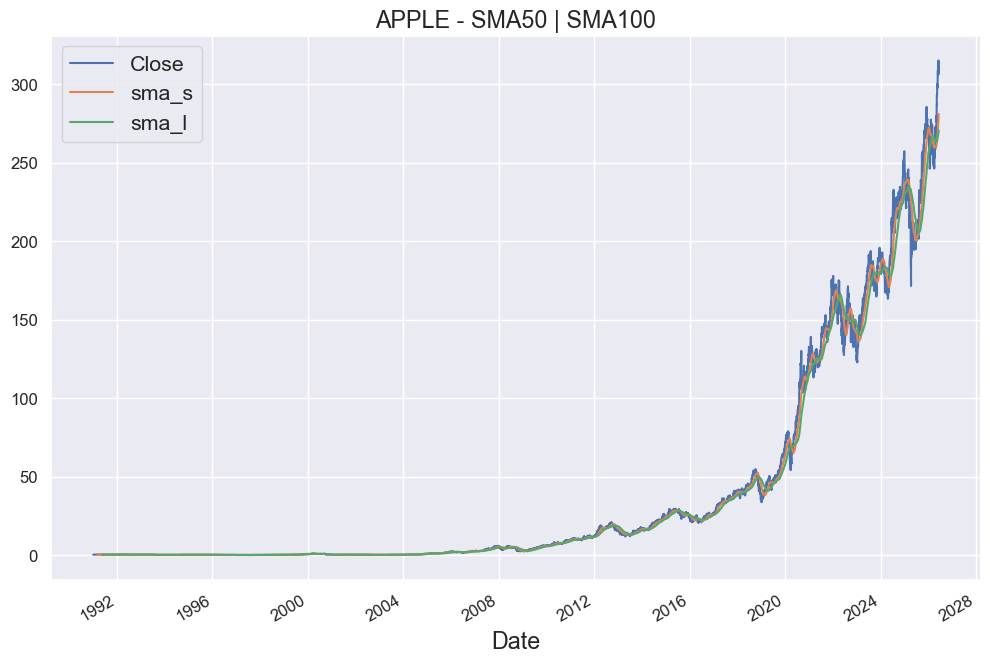

In [389]:
data.plot(figsize = (12,8), title = "APPLE - SMA{} | SMA{}".format(sma_s, sma_l), fontsize = 12) ## Graph of the columns from data

<Axes: title={'center': 'APPLE - SMA50 | SMA100'}, xlabel='Date'>

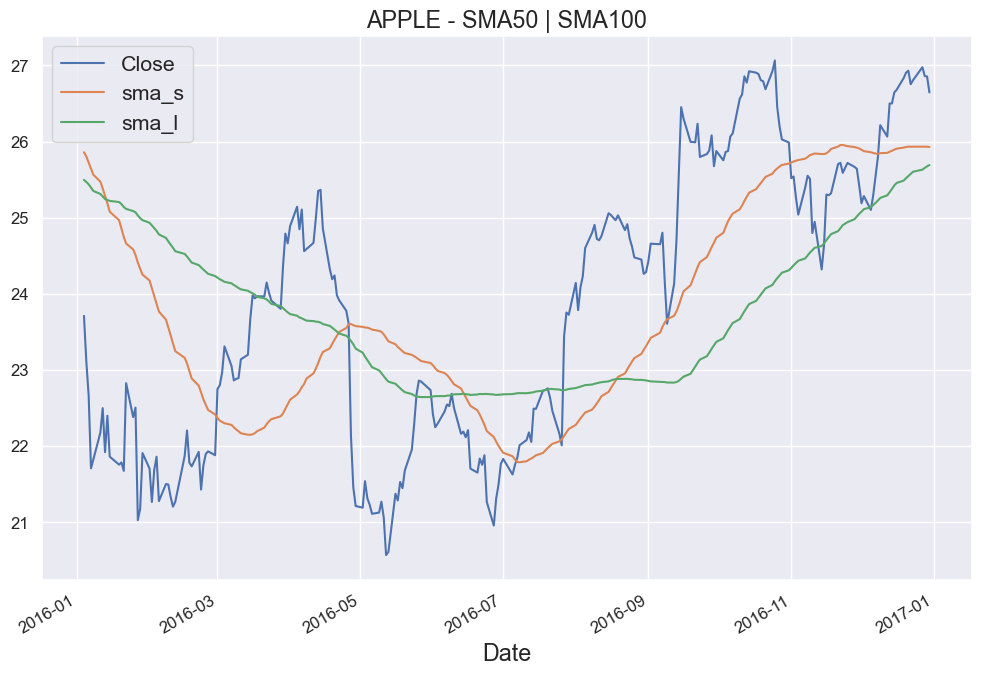

In [390]:
data.loc["2016"].plot(figsize = (12,8), title = "APPLE - SMA{} | SMA{}".format(sma_s, sma_l), fontsize = 12) ## Just the specific time peroid 

In [391]:
data.dropna(inplace = True) ## Getting rid of NaN data
data

,Close,sma_s,sma_l
Date,,,
1991-05-23,0.320940,0.424683,0.407643
1991-05-24,0.326274,0.421951,0.407826
1991-05-28,0.327163,0.419094,0.408054
1991-05-29,0.334276,0.416167,0.408335
1991-05-30,0.338720,0.413081,0.408660
...,...,...,...
2026-06-01,306.309998,276.260872,268.645094
2026-06-02,315.200012,277.609637,269.198622
2026-06-03,310.260010,278.789667,269.715626


### If SMA_s > SMA_l, we GO LONG 
### If SMA_l <= SMA_s, we GO SHORT 

In [393]:
data["position"] = np.where(data["sma_s"] > data["sma_l"], 1, -1) ## Creates a new column with sma_s and sma_l conditions 
data

,Close,sma_s,sma_l,position
Date,,,,
1991-05-23,0.320940,0.424683,0.407643,1
1991-05-24,0.326274,0.421951,0.407826,1
1991-05-28,0.327163,0.419094,0.408054,1
1991-05-29,0.334276,0.416167,0.408335,1
1991-05-30,0.338720,0.413081,0.408660,1
...,...,...,...,...
2026-06-01,306.309998,276.260872,268.645094,1
2026-06-02,315.200012,277.609637,269.198622,1
2026-06-03,310.260010,278.789667,269.715626,1


<Axes: title={'center': 'APPLE - SMA50 | SMA100'}, xlabel='Date'>

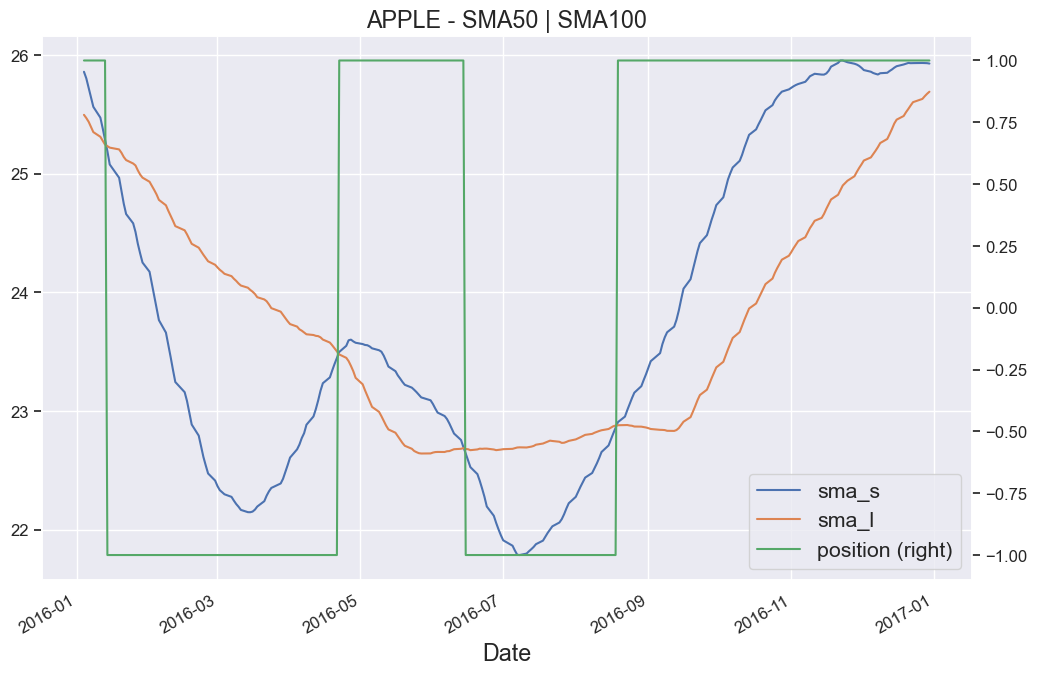

In [396]:
data.loc["2016",["sma_s", "sma_l","position"]].plot(figsize = (12,8), title = "APPLE - SMA{} | SMA{}".format(sma_s, sma_l), fontsize = 12, secondary_y = "position") 
## Includes same graph now with the position data

In [397]:
data["returnsb&h"] = np.log(data.Close.div(data.Close.shift(1)))
data

,Close,sma_s,sma_l,position,returnsb&h
Date,,,,,
1991-05-23,0.320940,0.424683,0.407643,1,NaN
1991-05-24,0.326274,0.421951,0.407826,1,0.016483
1991-05-28,0.327163,0.419094,0.408054,1,0.002721
1991-05-29,0.334276,0.416167,0.408335,1,0.021508
1991-05-30,0.338720,0.413081,0.408660,1,0.013209
...,...,...,...,...,...
2026-06-01,306.309998,276.260872,268.645094,1,-0.018598
2026-06-02,315.200012,277.609637,269.198622,1,0.028610
2026-06-03,310.260010,278.789667,269.715626,1,-0.015797


In [398]:
data["strategy"] = data["returnsb&h"]*data.position.shift(1)
data

,Close,sma_s,sma_l,position,returnsb&h,strategy
Date,,,,,,
1991-05-23,0.320940,0.424683,0.407643,1,NaN,NaN
1991-05-24,0.326274,0.421951,0.407826,1,0.016483,0.016483
1991-05-28,0.327163,0.419094,0.408054,1,0.002721,0.002721
1991-05-29,0.334276,0.416167,0.408335,1,0.021508,0.021508
1991-05-30,0.338720,0.413081,0.408660,1,0.013209,0.013209
...,...,...,...,...,...,...
2026-06-01,306.309998,276.260872,268.645094,1,-0.018598,-0.018598
2026-06-02,315.200012,277.609637,269.198622,1,0.028610,0.028610
2026-06-03,310.260010,278.789667,269.715626,1,-0.015797,-0.015797


In [399]:
data.dropna(inplace = True)

In [400]:
data[["returnsb&h", "strategy"]].sum()

returnsb&h    6.864455
strategy      1.632774
dtype: float64

In [401]:
data[["returnsb&h", "strategy"]].sum().apply(np.exp) ## What $1 will be 

returnsb&h    957.623525
strategy        5.118055
dtype: float64

In [402]:
data[["returnsb&h", "strategy"]].std()*np.sqrt(252)

returnsb&h    0.425618
strategy      0.425787
dtype: float64

<Axes: xlabel='Date'>

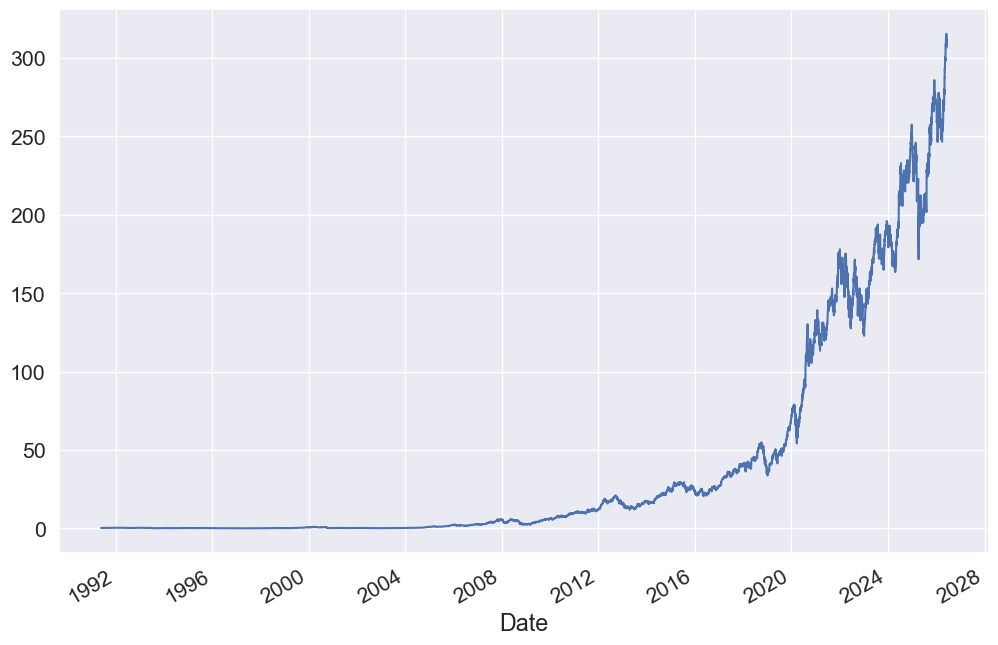

In [404]:
data.Close.plot(figsize = (12,8))

## Strategy adjusted with Long Bias. (no short position)

In [411]:
data["position2"] = np.where(data["sma_s"] > data["sma_l"], 1, 0)
data["strategy2"] = data["returnsb&h"]*data.position2.shift(1)
data.dropna(inplace = True)
data

,Close,sma_s,sma_l,position,returnsb&h,strategy,position2,strategy2
Date,,,,,,,,
1991-05-29,0.334276,0.416167,0.408335,1,0.021508,0.021508,1,0.021508
1991-05-30,0.338720,0.413081,0.408660,1,0.013209,0.013209,1,0.013209
1991-05-31,0.334276,0.410154,0.408941,1,-0.013209,-0.013209,1,-0.013209
1991-06-03,0.350278,0.407972,0.409241,-1,0.046761,0.046761,0,0.046761
1991-06-04,0.349389,0.405986,0.409398,-1,-0.002541,0.002541,0,-0.000000
...,...,...,...,...,...,...,...,...
2026-06-01,306.309998,276.260872,268.645094,1,-0.018598,-0.018598,1,-0.018598
2026-06-02,315.200012,277.609637,269.198622,1,0.028610,0.028610,1,0.028610
2026-06-03,310.260010,278.789667,269.715626,1,-0.015797,-0.015797,1,-0.015797


In [412]:
data[["returnsb&h", "strategy2"]].sum()

returnsb&h    6.845251
strategy2     4.229411
dtype: float64

In [413]:
data[["returnsb&h", "strategy2"]].sum().apply(np.exp) 

returnsb&h    939.408937
strategy2      68.676752
dtype: float64

In [415]:
data[["returnsb&h", "strategy2"]].std()*np.sqrt(252)

returnsb&h    0.425658
strategy2     0.328217
dtype: float64

### *We can see from our returns and risk that Strategy2 is better, since the stock seems to have a going long bias. This may be due to increase of apple products, AI dev, or any other reason.* 

In [418]:
data[["strategy", "strategy2"]].std()*np.sqrt(252)

strategy     0.425826
strategy2    0.328217
dtype: float64

### SMA strategy is pretty good. Might need to research the drawdowns for Long Only Bias, but they should be better.

# Creating our first function 

In [423]:
def test_strategy(stock, start, end, SMA):
    df = yf.download(stock, start = start, end = end)
    data = df[["Close"]].copy()
    data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
    data["SMA_S"] = data.Close.rolling(int(SMA[0])).mean()
    data["SMA_L"] = data.Close.rolling(int(SMA[1])).mean()
    data.dropna(inplace = True)

    data["position"] = np.where(data["SMA_S"] > data["SMA_L"], 1, -1)
    data["strategy"] = data["returns"]*data.position.shift(1)
    data.dropna(inplace = True)
    ret = np.exp(data["strategy"].sum())
    std = data["strategy"].std()*np.sqrt(252)

    return ret,std

In [435]:
test_strategy("AAPL", "2000-01-01", "2020-01-01", (50,200))

[*********************100%***********************]  1 of 1 completed


(np.float64(15.11030180735577), np.float64(0.3669423043057354))

### Keep this function, you can make changes to it as you want but serves as a good base. Helps show returns on the dollar with risk.

# Creating our First Class

In [545]:
class SMABacktester(): ## A class is a lot of functions in only one line of code, makes it very simple to program
    def __init__(self, symbol, SMA_S, SMA_L, start, end):
        self.symbol = symbol
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        self.start = start
        self.end = end
        self.results = None
        self.get_data()

    def get_data(self): 
        df = yf.download(self.symbol, start = self.start, end = self.end)

        # Might want to use the commented out code at some point in furture, not sure yet
        #if isinstance(df.columns, pd.MultiIndex):
        #df.columns = df.columns.get_level_values(0)
        
        data = df[["Close"]].copy()
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["SMA_S"] = data.Close.rolling(self.SMA_S).mean()
        data["SMA_L"] = data.Close.rolling(self.SMA_L).mean()
        data.dropna(inplace = True)
        self.data2 = data

        return data

    def test_results(self):
        data = self.data2.copy().dropna()
        data["position"] = np.where(data["SMA_S"] > data["SMA_L"], 1, -1)
        data["strategy"] = data["returns"]*data.position.shift(1)
        data.dropna(inplace = True)
        data["returnsBH"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        self.results = data
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsBH"].iloc[-1]
        
        ret = np.exp(data["strategy"].sum())
        std = data["strategy"].std()*np.sqrt(252)

        #return ret,std
        return round(perf,6), round(outperf,6)

    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else: 
            title = "{} | SMA_S = {} | SMA_L{}".format(self.symbol, self.SMA_S, self.SMA_L)
            self.results[["returnsBH", "returnsstrategy"]].plot(title = title, figsize = (12,8))
            plt.show()

In [558]:
tester = SMABacktester("AAPL", 1, 200, "2000-01-01", "2020-01-01")

[*********************100%***********************]  1 of 1 completed


In [559]:
tester.test_results()

(np.float64(211.711744), np.float64(-8.048767))

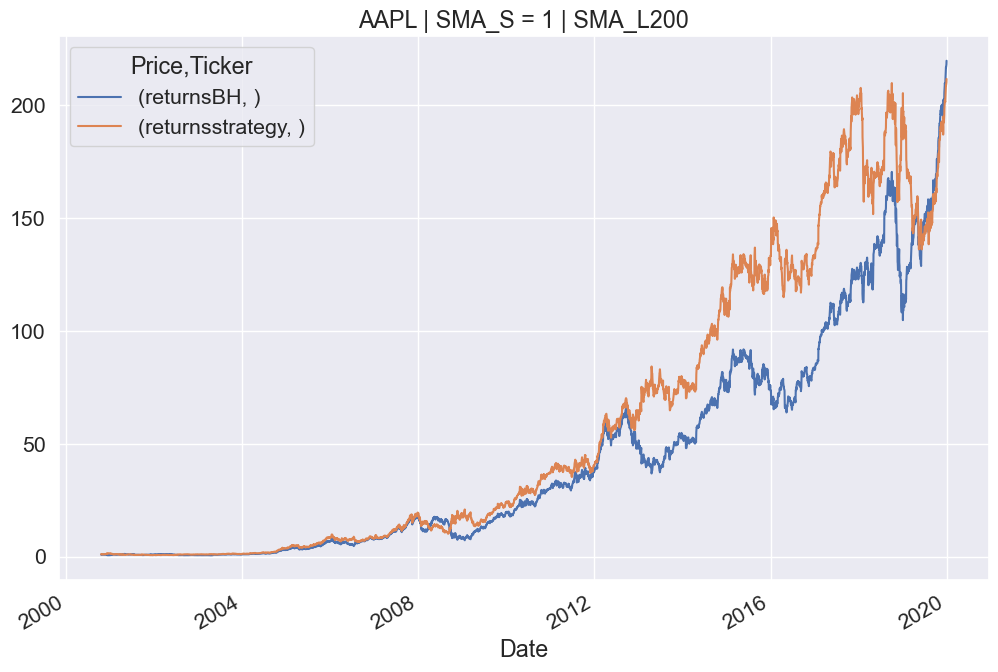

In [560]:
tester.plot_results()

In [ ]:
## Check out the Stan Wienstein Strategy in QuantProgram channel 